In [1]:
import pandas as pd
import numpy as np
import re
from scipy.stats import ttest_rel, wilcoxon
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load Recommendations

In [2]:
playlist_recommendation = pd.read_csv("recommendations_for_all_models_with_hybrid.csv")

In [3]:
### Test
playlist_test = pd.read_csv("playlist_final_unweighted.csv")
playlist_test = playlist_test[['playlist_idx', 'num_tracks', 'num_edits']]
playlist_recommendation = playlist_recommendation.merge(playlist_test, on='playlist_idx', how='inner')

In [4]:
def convert_string_array_to_list(s):
    """Convert a string representation of an array into a list of integers."""
    if isinstance(s, str):  # Handle string case (where it's incorrectly stored)
        numbers = re.findall(r'\d+', s)  # Extract all numeric values
        return [int(x) for x in numbers]  # Convert to integers
    
    elif isinstance(s, np.ndarray):  # Handle NumPy array case
        return s.astype(int).tolist()
    
    elif isinstance(s, list):  # Handle lists with possible string numbers
        return [int(x) for x in s if str(x).isdigit()]
    
    return []  # Return empty list if the format is unexpected

# Apply function and debug output
playlist_recommendation['tracks_to_predict'] = playlist_recommendation['tracks_to_predict'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['random_recommendations'] = playlist_recommendation['random_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['content_based_unweigted_recommendations'] = playlist_recommendation['content_based_unweigted_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['content_based_weigted_recommendations'] = playlist_recommendation['content_based_weigted_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['collaborative_filtering_recommendations'] = playlist_recommendation['collaborative_filtering_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['hybrid_recommendations'] = playlist_recommendation['hybrid_recommendations'].apply(lambda x: convert_string_array_to_list(x))

playlist_recommendation.head()

,playlist_idx,cluster,tracks_to_predict,random_recommendations,collaborative_filtering_recommendations,content_based_unweigted_recommendations,content_based_weigted_recommendations,hybrid_recommendations,num_tracks,num_edits
0,2,3,"[232845, 111887, 144160, 10663, 216321, 138869...","[174804, 45667, 180239, 72464, 155677, 131180,...","[174997, 175642, 186858, 72522, 111887, 55648,...","[26657, 102881, 169451, 97130, 76387, 177055, ...","[44021, 153676, 129186, 58351, 130032, 135471,...","[186858, 175642, 111887, 157693, 174997, 55648...",10,1
1,7,1,"[48557, 142203, 66610, 16213, 112277, 43008, 2...","[205630, 246877, 130193, 36681, 90295, 118324,...","[191313, 111863, 163571, 89133, 216260, 237774...","[121753, 168149, 245519, 129186, 140469, 10137...","[102680, 129186, 147304, 60873, 229551, 194684...","[191313, 111863, 163571, 216260, 89133, 237774...",75,49
2,10,0,"[89301, 74022, 221104, 218307, 229795, 129045,...","[123988, 154415, 107915, 207660, 19850, 7725, ...","[208248, 94251, 218307, 122853, 212881, 221104...","[137497, 208248, 83517, 3939, 26659, 234445, 6...","[208248, 232281, 144800, 240182, 44263, 63352,...","[208248, 94251, 218307, 8706, 122853, 212881, ...",52,3
3,17,2,"[131069, 102197, 241039, 46103, 41621, 213083,...","[117021, 227150, 234857, 240503, 162330, 37045...","[235367, 216374, 237415, 64550, 250306, 140314...","[237818, 208248, 156298, 237495, 194633, 25030...","[237818, 123797, 237495, 156298, 31218, 149917...","[235367, 216374, 237415, 64550, 54047, 14975, ...",63,28
4,28,2,"[166174, 63352, 37636, 75383, 195511, 131429, ...","[234157, 246389, 216575, 93478, 6884, 97278, 3...","[250306, 26659, 86790, 167186, 180201, 64550, ...","[29052, 26659, 251276, 208248, 234445, 250306,...","[26659, 234445, 251276, 250306, 245084, 29052,...","[250306, 26659, 86790, 167186, 64550, 180201, ...",32,5


# Code for Evaluation

In [5]:
def compute_metrics_for_playlist(predicted_tracks, test_indices, k):
    top_k = predicted_tracks[:k]  # Consider only top K predictions

    # Hit@K
    hit = int(any(t in top_k for t in test_indices))

    # MRR and AP calculations
    precisions = []
    num_hits = 0
    mrr = 0.0

    for rank_idx, track_idx in enumerate(top_k):
        if track_idx in test_indices:
            num_hits += 1
            precision_at_k = num_hits / (rank_idx + 1)
            precisions.append(precision_at_k)
            if mrr == 0.0:
                mrr = 1.0 / (rank_idx + 1)

    ap = np.mean(precisions) if precisions else 0.0

    return hit, mrr, ap

def evaluate_model(playlist, column_name, k):
    num_playlists = len(playlist)

    hit_total, mrr_total, ap_total = 0, 0, 0

    for idx, row in playlist.iterrows():
        test_indices = row['tracks_to_predict']
        predicted_tracks = row[column_name]

        hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)
        
        hit_total += hit
        mrr_total += mrr
        ap_total += ap

    # Compute averages
    hit_ratio = hit_total / num_playlists if num_playlists > 0 else 0
    mrr_avg = mrr_total / num_playlists if num_playlists > 0 else 0
    map_avg = ap_total / num_playlists if num_playlists > 0 else 0

    return hit_ratio, mrr_avg, map_avg, column_name

def evaluate_model_hypo(playlist, column_name, k, return_all=False):
    hits, mrrs, aps = [], [], []

    for idx, row in playlist.iterrows():
        test_indices = row['tracks_to_predict']
        predicted_tracks = row[column_name]

        hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)
        
        hits.append(hit)
        mrrs.append(mrr)
        aps.append(ap)

    if return_all:
        return hits, mrrs, aps  # return lists for paired testing
    else:
        num_playlists = len(hits)
        hit_ratio = sum(hits) / num_playlists if num_playlists > 0 else 0
        mrr_avg = sum(mrrs) / num_playlists if num_playlists > 0 else 0
        map_avg = sum(aps) / num_playlists if num_playlists > 0 else 0
        return hit_ratio, mrr_avg, map_avg, column_name

def compare_models(playlist, model_a_col, model_b_col, k):
    # Get per-playlist metrics
    hits_a, mrrs_a, aps_a = evaluate_model_hypo(playlist, model_a_col, k, return_all=True)
    hits_b, mrrs_b, aps_b = evaluate_model_hypo(playlist, model_b_col, k, return_all=True)

    # Paired t-tests
    t_hit, p_hit = ttest_rel(hits_a, hits_b)
    t_mrr, p_mrr = ttest_rel(mrrs_a, mrrs_b)
    t_ap, p_ap = ttest_rel(aps_a, aps_b)

    return {
        "Hit@K": {"t-stat": t_hit, "p-value": p_hit},
        "MRR": {"t-stat": t_mrr, "p-value": p_mrr},
        "MAP": {"t-stat": t_ap, "p-value": p_ap}
    }

def evaluate_model_by_cluster(playlist, column_name, k, cluster_column):
    # Group by the cluster column
    clusters = playlist.groupby(cluster_column)
    
    cluster_metrics = {}

    for cluster, cluster_data in clusters:
        # Initialize total metrics for the current cluster
        hit_total, mrr_total, ap_total = 0, 0, 0

        for idx, row in cluster_data.iterrows():
            test_indices = row['tracks_to_predict']
            predicted_tracks = row[column_name]

            hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)

            hit_total += hit
            mrr_total += mrr
            ap_total += ap

        # Compute averages for the current cluster
        num_playlists = len(cluster_data)
        hit_ratio = hit_total / num_playlists if num_playlists > 0 else 0
        mrr_avg = mrr_total / num_playlists if num_playlists > 0 else 0
        map_avg = ap_total / num_playlists if num_playlists > 0 else 0

        # Store the metrics for the current cluster
        cluster_metrics[cluster] = {
            "Hit@K": hit_ratio,
            "MRR": mrr_avg,
            "MAP": map_avg
        }

    return cluster_metrics

def evaluate_row_metrics(row, column_name, k):
    test_indices = row['tracks_to_predict']
    predicted_tracks = row[column_name]

    hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)
    
    return hit, mrr, ap

def create_metrics_dataframe(playlist, column_name, k, cluster_column):
    # Apply the evaluate_row_metrics function to each row
    metrics = playlist.apply(lambda row: evaluate_row_metrics(row, column_name, k), axis=1)
    
    # Create a new dataframe with the metrics
    metrics_df = pd.DataFrame(metrics.tolist(), columns=["Hit@K", "MRR", "MAP"])
    metrics_df[cluster_column] = playlist[cluster_column].values  # Add the cluster information

    return metrics_df

# Level 4: Comparing Hybrid Model against Content Based Model & Collaborative Filtering

## Model Performance

Hybrid Model

In [6]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'hybrid_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for hybrid_recommendations
Hit@50: 0.5721
MRR: 0.1349
MAP@50: 0.0967


Content Based Model

In [7]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'content_based_unweigted_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for content_based_unweigted_recommendations
Hit@50: 0.3582
MRR: 0.0757
MAP@50: 0.0613


Collaborative Filtering

In [8]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'collaborative_filtering_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for collaborative_filtering_recommendations
Hit@50: 0.5673
MRR: 0.1372
MAP@50: 0.0982


## Hybrid Model vs Content Based

We will conduct a one-sided paired 2-sample hypothesis test at 5% level of significance

\begin{aligned}
H_0 &: \mu_{\text{content based}} \ge \mu_{\text{hybrid}} \quad \text{(Content based performs at least as well as hybrid)} \\
H_1 &: \mu_{\text{content based}} < \mu_{\text{hybrid}} \quad \text{(Hybrid performs better than content based)}
\end{aligned}

In [9]:
results = compare_models(
    playlist_recommendation,
    "content_based_unweigted_recommendations",
    "hybrid_recommendations",
    k=50
)

alpha = 0.05  # significance level

print("Hypothesis Test between Content Based vs Hybrid Model")

for metric, res in results.items():
    t_stat = res['t-stat']
    two_sided_p_val = res['p-value']
    one_sided_p_val = two_sided_p_val / 2

    print(f"\n=== {metric} Comparison ===")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"one-sided p-value: {one_sided_p_val:.4f}")

Hypothesis Test between Content Based vs Hybrid Model

=== Hit@K Comparison ===
t-statistic: -15.986
one-sided p-value: 0.0000

=== MRR Comparison ===
t-statistic: -8.696
one-sided p-value: 0.0000

=== MAP Comparison ===
t-statistic: -7.333
one-sided p-value: 0.0000


### Hypothesis Test Conclusion (Content Based vs Hybrid Model)
Since the p-value for all 3 metrics are close to 0, we can reject the null hypothesis and conclude that the hybrid model performs better than the content based.

### Business Evaluation:
Content-based models rely solely on metadata features (e.g. audio, lyrical), so they personalise based on what a user liked in the past.

On the contrary, hybrid models integrate content + collaborative signals, improving ranking of relevant items because they factor in:
- What similar users like
- What the user personally prefers

This is why hybrid models achieve better Hit@50, MRR, and MAP.

## Hybrid Model vs Collaborative Filtering

We will conduct a one-sided paired 2-sample hypothesis test at 5% level of significance

\begin{aligned}
H_0 &: \mu_{\text{collaborative filtering}} \ge \mu_{\text{hybrid}} \quad \text{(Collaborative filtering performs at least as well as hybrid)} \\
H_1 &: \mu_{\text{collaborative filtering}} < \mu_{\text{hybrid}} \quad \text{(Hybrid performs better than Collaborative filtering)}
\end{aligned}

In [10]:
results = compare_models(
    playlist_recommendation,
    "collaborative_filtering_recommendations",
    "hybrid_recommendations",
    k=50
)

alpha = 0.05  # significance level

print("Hypothesis Test between Collaborative Filtering vs Hybrid Model")

for metric, res in results.items():
    t_stat = res['t-stat']
    two_sided_p_val = res['p-value']
    one_sided_p_val = two_sided_p_val / 2

    print(f"\n=== {metric} Comparison ===")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"one-sided p-value: {one_sided_p_val:.4f}")

Hypothesis Test between Collaborative Filtering vs Hybrid Model

=== Hit@K Comparison ===
t-statistic: -1.260
one-sided p-value: 0.1038

=== MRR Comparison ===
t-statistic: 1.271
one-sided p-value: 0.1019

=== MAP Comparison ===
t-statistic: 1.220
one-sided p-value: 0.1113


### Hypothesis Test Conclusion (Collaborative Filtering vs Hybrid Model)
The p-value for Hit@K, MRR and MAP are all > 0.05 (although it is still not large). Therefore, we are unable to reject the null hypothesis and conclude that the collaborative filtering performs at least as well as the hybrid model.

However, the hybrid model is more flexible, and able to combine the strengths of both content based and collaborative filtering.

As shown in level 3 analysis, the content based and collaborative filtering performance differs based on the cluster. As such, we **will continue** to use the hybrid model.

### Business Evaluation:
Collaborative filtering assumes users with similar interactions will like similar items. It works great for popular clusters (mainstream users), but fails for:
- Sparse data
- Users with diverse taste

Our hybrid model solves this by using item features to fill in gaps in user-user similarity, maintaining high accuracy across all clusters.

## Limitations with Accuracy Metrics

The accuracy metrics used in our evaluation include:
1. Hit@50: Measures whether at least one of the top-50 recommended songs is in the user’s actual preference (e.g., what they ended up listening to).
2. MRR: Measures the inverse rank of the first relevant song. Higher if relevant songs are ranked at the top.
3. MAP@50: Averages the precision scores at the ranks where relevant songs appear, up to rank 50.

### 1. Lack of Personalization Insight
These metrics focus only on whether the correct items are retrieved and ranked high, but not whether those items are personally meaningful or contextually relevant to the user.

They don’t reflect user-specific tastes, moods, or intentions, which are specific and crucial to our business problem as a Playlist recommendation system.

### 2. No Consideration of Diversity or Serendipity
All three metrics reward recommending relevant items, but not diverse or novel ones.

This may lead to the "rich get richer" problem, where models prioritise popular items that are already likely to be clicked, reinforcing filter bubbles.

### 3. Binary Relevance Assumption
These metrics usually treat items as either "relevant" or "not" (e.g. a track is in the ground truth or not), ignoring degrees of preference.

In reality, a user may like several songs with varying intensities, but these metrics do not capture that possibility well.

### 4. Position Sensitivity (or Insensitivity)
MRR is very sensitive to the first relevant item. It is good for certain use cases (e.g. one-click conversion), but not ideal for scenarios like playlists where multiple items matter.

Hit@50 is not position-sensitive at all, as long as the item is somewhere in the top 50, it ignores ranking quality within that range.

## New Behavioural Metrics

While accuracy metrics like **HitRatio@50**, **MRR**, and **MAP@50** measure **how well** a recommendation matches a user’s past behavior, they often miss **how satisfying** or **meaningful** the recommendations are. In reality, users do not just want more of what they already like, but they want to **discover**, be **surprised**, and feel that the recommendations are **relevant** to their unique tastes.

**Behavioral metrics** help evaluate what accuracy alone can’t:
- Personalisation depth  
- Diversity of music exposure  
- Delight in unexpected discovery  
- Long-term user engagement

---

Behavioural Metric 1: **Diversity**

**Definition:**  
Measures how different the recommended songs are from each other, often based on metadata like genre, artist, or audio features (e.g., tempo, mood).

**Why It Matters:**
- Prevents repetitiveness in playlists
- Encourages exploration across genres or styles
- Increases long-term user satisfaction by reducing boredom

**Computation:**
- Find the pairwise cosine similarity of the tracks that are recommended (does not take into the consideration of the hidden tracks)
---

Behavioural Metric 2: **Serendipity**

**Definition:**  
Measures how **unexpected but pleasing** the recommended songs are, i.e., songs the user didn’t know they’d like.

**Why It Matters:**
- Captures the "wow" factor of music discovery
- Goes beyond safe, obvious picks
- Helps uncover **new favorite songs**

**Computation:**
- Find the cosine dissimilarity of the each tracks that are recommended to the playlist’s features (novelty)
- Multiply the relavence score with the novelty score
---

Behavioural Metric 3: **Relevance**

**Definition:**  
Measures how well the recommended songs **align with the user’s current preferences** or contextual needs.

**Why It Matters:**
- Core to perceived usefulness
- Ensures that diversity/serendipity don’t come at the cost of quality
- Can be based on either **explicit feedback** (likes) or **implicit signals** (skips, replays)

**Computation:**
- Find the cosine similarity between the hidden tracks and the recommended tracks for every pair
---

### Behavioural + Accuracy = A Holistic Evaluation

| Metric Type     | Measures...                        | Captures...                                  |
|-----------------|------------------------------------|-----------------------------------------------|
| Accuracy (Hit@50, MRR, MAP@50) | Matching past behavior             | How well songs rank compared to past choices |
| **Diversity**   | Intra-list variability             | Breadth of recommendations                    |
| **Serendipity** | Unexpected, delightful surprises   | Novel but satisfying content                  |
| **Relevance**   | Perceived match to user taste      | Personalized enjoyment                        |

Combined, these metrics help ensure Spotifind does not just *recommend correctly*, but also helps to *explore musically*.

**Thus, we shall now focus on the behavioural metrics.**

## Model Performance using Behavioural Metrics

### Load Datasets

In [11]:
tracks = pd.read_parquet("track_final.parquet")
playlist_original = pd.read_csv("playlist_final_unweighted.csv")

### Manipulation

In [12]:
tracks['track_popularity'] = tracks['track_popularity'] / 100
tracks['track_idx'] = tracks['track_idx'].astype(int)
tracks = tracks.set_index('track_idx')
playlist_original['popularity_mean'] = playlist_original['popularity_mean'] / 100
playlist_original['playlist_idx'] = playlist_original['playlist_idx'].astype(int)
behavioural_scores = playlist_recommendation[['playlist_idx', 'cluster', 'tracks_to_predict']]

In [13]:
tracks_relevant_columns = tracks[['track_popularity',
                                  'Early Years', 'Classic Era', 'Golden Era', '2000s', 'Modern Era',
                                  'Short', 'Medium', 'Long',
                                  "joy", "calm", "sadness", "fear", "energizing", "dreamy",
                                  "Instrumental / Ambient Sounds", "Soft Acoustic / Classical", "Orchestral / Soundtrack", "Mid-tempo Pop / Indie", "Upbeat Electronic / Dance", "Slow & Melancholic (Sad Songs)", "Experimental / Jazz Fusion", "Lo-Fi / Chill Vibes"]]

In [14]:
playlist_original['sentiment_centroid'] = playlist_original['sentiment_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))
playlist_original['genre_centroid'] = playlist_original['genre_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Unpack the column into separate columns
playlist_original[['genre1', 'genre2', 'genre3', 'genre4', 'genre5', 'genre6', 'genre7', 'genre8']] = pd.DataFrame(playlist_original['genre_centroid'].tolist())

# Drop the original column if you no longer need it
playlist_original = playlist_original.drop(columns=['genre_centroid'])

# Unpack the column into separate columns
playlist_original[['sent1', 'sent2', 'sent3', 'sent4', 'sent5', 'sent6']] = pd.DataFrame(playlist_original['sentiment_centroid'].tolist())

# Drop the original column if you no longer need it
playlist_original = playlist_original.drop(columns=['sentiment_centroid'])

playlist_relevant_columns = playlist_original[['popularity_mean', 
                                      'era_early_years_proportion', 'era_classic_era_proportion', 'era_golden_era_proportion', 'era_2000s_proportion', 'era_modern_era_proportion',
                                      'length_short_proportion', 'length_medium_proportion', 'length_long_proportion',
                                      'sent1', 'sent2', 'sent3', 'sent4', 'sent5', 'sent6',
                                      'genre1', 'genre2', 'genre3', 'genre4', 'genre5', 'genre6', 'genre7', 'genre8']]

playlist_original = playlist_original.set_index('playlist_idx')

### Code for Evaluation

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

def avg_cosine_similarity(set_a, set_b, tracks_df, track_feat_columns):
    """
    Computes the average cosine similarity between all track pairs (a, b)
    where a ∈ set_a and b ∈ set_b, based on the provided track feature columns.
    """
    # Convert set_a and set_b to list if they are not already
    set_a = list(set_a)
    set_b = list(set_b)
    
    # Make sure that the track indices are valid
    a_vectors = tracks_df.loc[set_a, track_feat_columns].values
    b_vectors = tracks_df.loc[set_b, track_feat_columns].values
    
    if a_vectors.shape[0] == 0 or b_vectors.shape[0] == 0:
        return 0.0  # Avoid similarity calculation if vectors are empty

    # Compute the cosine similarity between all pairs of tracks in a_vectors and b_vectors
    sim_matrix = cosine_similarity(a_vectors, b_vectors)
    return sim_matrix.mean()

# Example: To apply this on each playlist
def compute_relevance_for_playlist(row, tracks_df, track_feat_columns):
    true_tracks = row['tracks_to_predict']
    recommended_tracks = row['hybrid_recommendations']
    
    # Calculate cosine similarity for the top k recommended tracks and true tracks
    sim_score = avg_cosine_similarity(recommended_tracks, true_tracks, tracks_df, track_feat_columns)
    return sim_score

def calculate_diversity_score(recommended_tracks, tracks_df, track_feat_columns):
    """
    Calculate the diversity score for a given set of recommended tracks.
    The diversity score is based on the average pairwise cosine similarity between recommended tracks.
    A lower cosine similarity indicates higher diversity.
    """
    # Extract the feature vectors of the recommended tracks
    recommended_vectors = tracks_df.loc[recommended_tracks, track_feat_columns].values
    
    if recommended_vectors.shape[0] == 0:
        return 0.0  # If there are no recommended tracks, return a default score
    
    # Compute the pairwise cosine similarity between all recommended tracks
    sim_matrix = cosine_similarity(recommended_vectors)
    
    # We remove the diagonal of the similarity matrix, as it represents self-similarity
    np.fill_diagonal(sim_matrix, 0)  # Set the diagonal to 0 to ignore self-similarity
    
    # Calculate the average of the off-diagonal similarities
    avg_similarity = sim_matrix.sum() / (sim_matrix.shape[0] * (sim_matrix.shape[0] - 1))
    
    # Diversity score: lower cosine similarity means higher diversity
    diversity_score = 1 - avg_similarity  # You can also directly return avg_similarity if you prefer
    
    return diversity_score

# Example: Apply this to each playlist
def compute_diversity_for_playlist(row, tracks_df, track_feat_columns):
    recommended_tracks = row['hybrid_recommendations']
    
    # Calculate the diversity score for the recommended tracks
    diversity_score = calculate_diversity_score(recommended_tracks, tracks_df, track_feat_columns)
    return diversity_score

def compute_novelty(row, playlist_relevant_df, tracks_df, playlist_feat_columns, track_feat_columns):
    # Get playlist feature vector (assume index of row matches that in playlist_relevant_df)
    playlist_vector = playlist_relevant_df.loc[row.name, playlist_feat_columns].values.reshape(1, -1)

    # Get track IDs for recommended tracks
    recommended_ids = row['hybrid_recommendations']
    
    # Make sure it's a list of valid indices
    recommended_ids = list(recommended_ids)
    
    # Get feature vectors for recommended tracks
    track_vectors = tracks_df.loc[recommended_ids, track_feat_columns].values
    
    if track_vectors.shape[0] == 0:
        return 0.0  # Avoid errors on empty recommended lists
    
    # Compute cosine similarity between playlist and each recommended track
    sim_scores = cosine_similarity(playlist_vector, track_vectors)[0]  # Shape (n_tracks,)
    
    # Novelty = 1 - average similarity
    novelty_score = 1 - np.mean(sim_scores)
    return novelty_score

### Model Performance

In [16]:
# Apply this to the dataset and create a new column in the `playlist_recommendation` DataFrame
behavioural_scores['relevance'] = playlist_recommendation.apply(compute_relevance_for_playlist, axis=1, 
                                               tracks_df=tracks, track_feat_columns=tracks_relevant_columns.columns)

print("Behaviorial Metrics of Hybrid Model:\n")

# Print the updated DataFrame
print("Mean relevance:", behavioural_scores['relevance'].mean())

# Apply this function to the playlist_recommendation DataFrame to get the diversity score for each playlist
behavioural_scores['diversity'] = playlist_recommendation.apply(compute_diversity_for_playlist, axis=1, 
                                          tracks_df=tracks, track_feat_columns=tracks_relevant_columns.columns)

# Print the dataframe with the diversity scores
print("Mean diversity:", behavioural_scores['diversity'].mean())

# Align indices
playlist_recommendation = playlist_recommendation.reset_index(drop=True)
playlist_original = playlist_original.reset_index(drop=True)

behavioural_scores['novelty'] = playlist_recommendation.apply(
    compute_novelty,
    axis=1,
    playlist_relevant_df=playlist_original,
    tracks_df=tracks,
    playlist_feat_columns=playlist_relevant_columns.columns,
    track_feat_columns=tracks_relevant_columns.columns
)

behavioural_scores['serendipity'] = behavioural_scores['relevance'] * behavioural_scores['novelty']

print("Mean serendipity:", behavioural_scores['serendipity'].mean())

Behaviorial Metrics of Hybrid Model:

Mean relevance: 0.595078051420322
Mean diversity: 0.3678740777004167
Mean serendipity: 0.17801161832300227


# Testing

In [232]:
track_df = pd.read_parquet("track_final.parquet")


In [155]:
playlist_recommendation

,playlist_idx,cluster,tracks_to_predict,random_recommendations,collaborative_filtering_recommendations,content_based_unweigted_recommendations,content_based_weigted_recommendations,hybrid_recommendations,num_tracks,num_edits
0,2,3,"[232845, 111887, 144160, 10663, 216321, 138869...","[174804, 45667, 180239, 72464, 155677, 131180,...","[174997, 175642, 186858, 72522, 111887, 55648,...","[26657, 102881, 169451, 97130, 76387, 177055, ...","[44021, 153676, 129186, 58351, 130032, 135471,...","[186858, 175642, 111887, 157693, 174997, 55648...",10,1
1,7,1,"[48557, 142203, 66610, 16213, 112277, 43008, 2...","[205630, 246877, 130193, 36681, 90295, 118324,...","[191313, 111863, 163571, 89133, 216260, 237774...","[121753, 168149, 245519, 129186, 140469, 10137...","[102680, 129186, 147304, 60873, 229551, 194684...","[191313, 111863, 163571, 216260, 89133, 237774...",75,49
2,10,0,"[89301, 74022, 221104, 218307, 229795, 129045,...","[123988, 154415, 107915, 207660, 19850, 7725, ...","[208248, 94251, 218307, 122853, 212881, 221104...","[137497, 208248, 83517, 3939, 26659, 234445, 6...","[208248, 232281, 144800, 240182, 44263, 63352,...","[208248, 94251, 218307, 8706, 122853, 212881, ...",52,3
3,17,2,"[131069, 102197, 241039, 46103, 41621, 213083,...","[117021, 227150, 234857, 240503, 162330, 37045...","[235367, 216374, 237415, 64550, 250306, 140314...","[237818, 208248, 156298, 237495, 194633, 25030...","[237818, 123797, 237495, 156298, 31218, 149917...","[235367, 216374, 237415, 64550, 54047, 14975, ...",63,28
4,28,2,"[166174, 63352, 37636, 75383, 195511, 131429, ...","[234157, 246389, 216575, 93478, 6884, 97278, 3...","[250306, 26659, 86790, 167186, 180201, 64550, ...","[29052, 26659, 251276, 208248, 234445, 250306,...","[26659, 234445, 251276, 250306, 245084, 29052,...","[250306, 26659, 86790, 167186, 64550, 180201, ...",32,5
...,...,...,...,...,...,...,...,...,...,...
1846,19948,1,"[92421, 249774, 198293, 166866, 74901, 28526, ...","[103218, 137568, 119423, 176275, 36407, 34551,...","[87405, 186690, 57687, 148812, 80634, 208730, ...","[168149, 93035, 123704, 21931, 141508, 95510, ...","[208248, 247320, 238860, 17147, 95724, 206182,...","[87405, 186690, 148812, 57687, 80634, 208730, ...",50,11
1847,19950,1,"[12369, 51140, 214636, 204790, 82682, 63624, 1...","[93623, 96275, 40056, 226036, 70903, 199885, 1...","[16769, 86790, 64550, 116049, 250306, 251689, ...","[208248, 250306, 237818, 237495, 156298, 36171...","[250306, 237495, 191269, 237818, 123797, 23228...","[16769, 86790, 116049, 64550, 250306, 251689, ...",105,79
1848,19953,1,"[24004, 54530, 219046, 69275, 57996, 229720, 1...","[185958, 205732, 102951, 233104, 126668, 16404...","[180201, 116049, 168606, 202106, 45282, 121753...","[29052, 26659, 250306, 208248, 93035, 219881, ...","[26659, 250306, 96552, 208248, 123704, 221079,...","[180201, 72522, 168606, 202106, 116049, 45282,...",139,54
1849,19988,3,"[120386, 156298, 168129, 148509, 242528, 7246,...","[88666, 129499, 148035, 246562, 207822, 174181...","[235367, 237415, 250306, 86790, 16769, 195884,...","[208248, 250306, 26659, 237495, 180201, 3939, ...","[208248, 250306, 232281, 147415, 26659, 235367...","[235367, 237415, 16769, 86790, 250306, 84826, ...",165,81


In [252]:
import pandas as pd

# Explode the list into separate rows
track_popularity_df = track_df.copy()
track_popularity_df = track_popularity_df[['track_idx', 'track_popularity', 'artist_idx']]

exploded_df = playlist_recommendation.explode('hybrid_recommendations').reset_index(drop=True)

# Rename for clarity
exploded_df = exploded_df.rename(columns={'hybrid_recommendations': 'track_idx'})
exploded_df = exploded_df.merge(track_popularity_df, on='track_idx', how='left')

# Count the frequency of each track_idx
top_tracks = exploded_df['track_idx'].value_counts().head(10).reset_index()

# Rename columns for clarity
top_tracks.columns = ['track_idx', 'count']

print(top_tracks)

   track_idx  count
0     103098    699
1     191177    696
2     237495    682
3     116049    655
4     104413    639
5      35237    621
6     235367    580
7     180201    559
8      72522    556
9      68844    543


popularity_bin
0    15333
1     3293
2     1176
3      791
4     1688
5     1295
6     1725
7     3076
8     9644
9    54529
dtype: int64


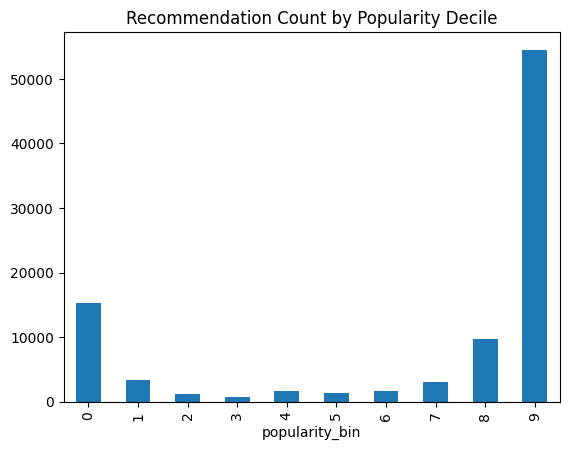

In [253]:
unique_tracks = exploded_df[['track_idx', 'track_popularity']]

# Step 1: Compute the quantile bins from track_df
popularity_bins = pd.qcut(track_df['track_popularity'], q=10, labels=False, duplicates='drop')

# Step 2: Assign these bins back to track_df temporarily
track_df = track_df.copy()
track_df['popularity_bin'] = popularity_bins

# Step 3: Merge the bin info into exploded_df based on track_id or another unique key
unique_tracks = unique_tracks.merge(track_df[['track_idx', 'popularity_bin']], on='track_idx', how='left')

# Step 4: Plot
unique_tracks.groupby('popularity_bin').size().plot(
    kind='bar',
    title='Recommendation Count by Popularity Decile'
)

print(unique_tracks.groupby('popularity_bin').size())

In [187]:
popularity_bins

0         2
1         2
2         3
3         7
4         0
         ..
252231    0
252232    6
252233    3
252234    5
252235    2
Name: track_popularity, Length: 252236, dtype: int64

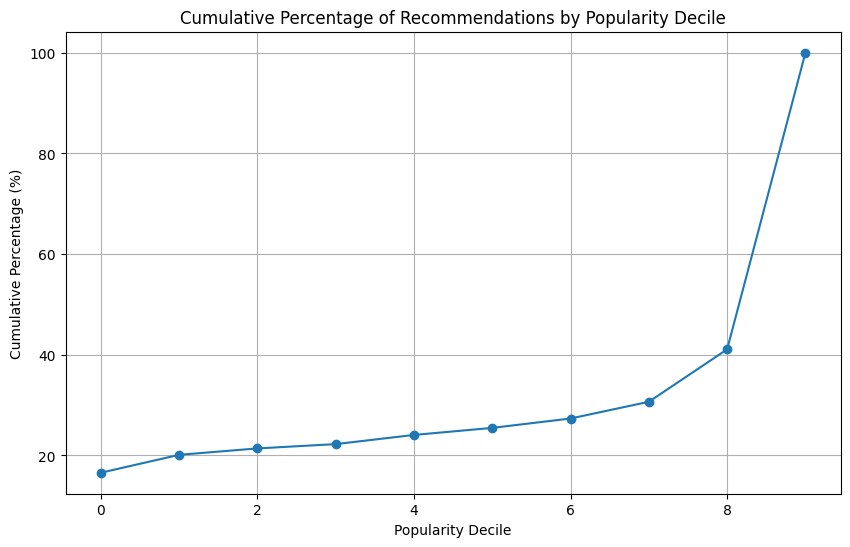

In [254]:
import matplotlib.pyplot as plt

# Calculate the count of recommendations per bin
recommendation_count = unique_tracks.groupby('popularity_bin').size()

# Calculate the cumulative sum of recommendations
cumulative_count = recommendation_count.cumsum()

# Calculate the total number of recommendations
total_recommendations = recommendation_count.sum()

# Calculate the cumulative percentage
cumulative_percentage = (cumulative_count / total_recommendations) * 100
# Plot the cumulative percentage
plt.figure(figsize=(10, 6))
cumulative_percentage.plot(kind='line', marker='o', title='Cumulative Percentage of Recommendations by Popularity Decile')
plt.xlabel('Popularity Decile')
plt.ylabel('Cumulative Percentage (%)')
plt.grid(True)
plt.show()

<Axes: title={'center': 'Recommendation Count by Popularity Decile'}, xlabel='popularity_bin'>

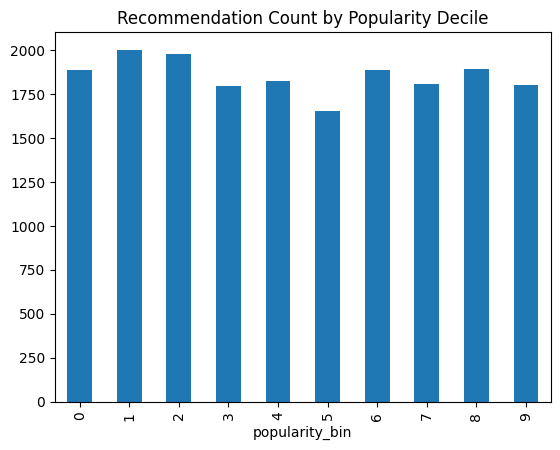

In [239]:
# Now bin tracks into popularity percentiles
exploded_df['popularity_bin'] = pd.qcut(track_df['track_popularity'], q=10, labels=False)

# Plot: Number of times recommended in each popularity bin
exploded_df.groupby('popularity_bin').size().plot(kind='bar', title='Recommendation Count by Popularity Decile')

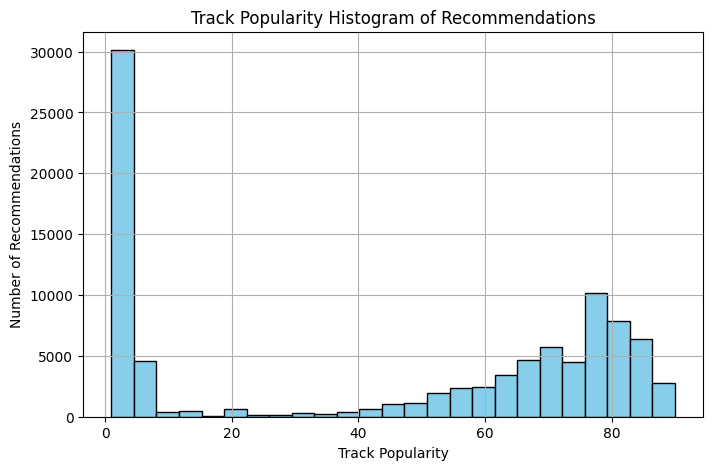

In [171]:
plt.figure(figsize=(8, 5))
plt.hist(exploded_df['track_popularity'], bins=25, color='skyblue', edgecolor='black')
plt.xlabel('Track Popularity')
plt.ylabel('Number of Recommendations')
plt.title('Track Popularity Histogram of Recommendations')
plt.grid(True)
plt.show()

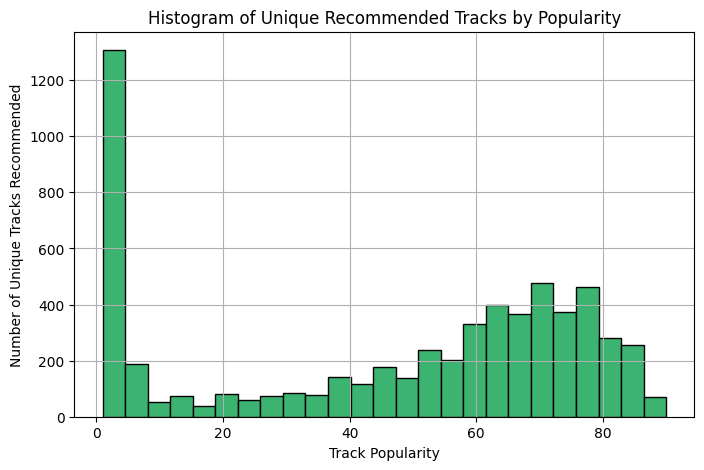

In [172]:
unique_tracks = exploded_df[['track_idx', 'track_popularity']].drop_duplicates()

plt.figure(figsize=(8, 5))
plt.hist(unique_tracks['track_popularity'], bins=25, color='mediumseagreen', edgecolor='black')
plt.xlabel('Track Popularity')
plt.ylabel('Number of Unique Tracks Recommended')
plt.title('Histogram of Unique Recommended Tracks by Popularity')
plt.grid(True)
plt.show()

In [174]:
import matplotlib.pyplot as plt

# Bin tracks into popularity percentiles
exploded_df['popularity_bin'] = pd.qcut(exploded_df['track_popularity'], q=10, labels=False)

# Calculate the count of recommendations per bin
recommendation_count = exploded_df.groupby('popularity_bin').size()

# Calculate the cumulative sum of recommendations
cumulative_count = recommendation_count.cumsum()

# Calculate the total number of recommendations
total_recommendations = recommendation_count.sum()

# Calculate the cumulative percentage
cumulative_percentage = (cumulative_count / total_recommendations) * 100

# Plot the cumulative percentage
plt.figure(figsize=(10, 6))
cumulative_percentage.plot(kind='line', marker='o', title='Cumulative Percentage of Recommendations by Popularity Decile')
plt.xlabel('Popularity Decile')
plt.ylabel('Cumulative Percentage (%)')
plt.grid(True)
plt.show()

ValueError: Bin edges must be unique: Index([1.0, 1.0, 2.0, 3.0, 36.0, 60.0, 69.0, 75.0, 79.0, 82.0, 90.0], dtype='float64', name='track_popularity').
You can drop duplicate edges by setting the 'duplicates' kwarg

<Axes: title={'center': 'Unique Tracks Recommended by Popularity Decile'}, xlabel='popularity_bin'>

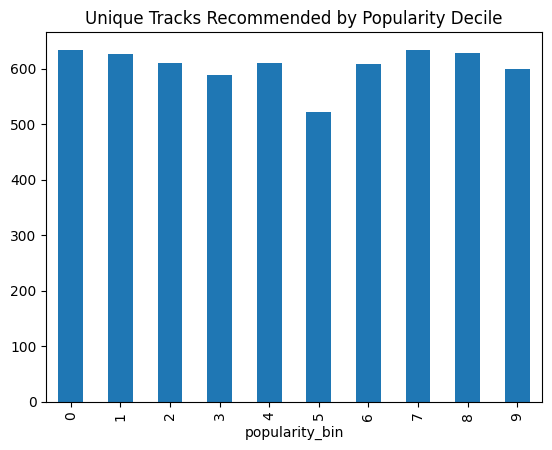

In [175]:
exploded_df.drop_duplicates('track_idx').groupby('popularity_bin').size().plot(
    kind='bar',
    title='Unique Tracks Recommended by Popularity Decile'
)

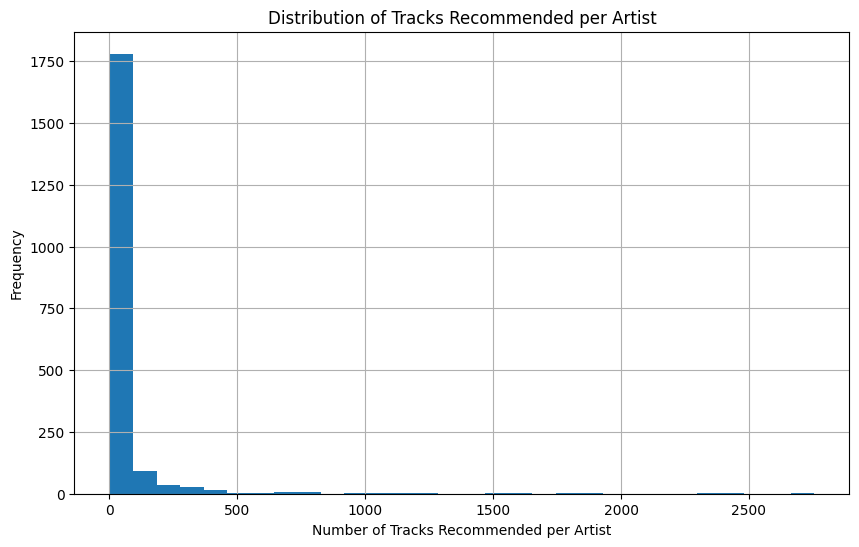

In [89]:
# Count the number of recommended tracks per artist
artist_recommendation_count = exploded_df.groupby('artist_idx').size()

# Plot the distribution of recommended tracks per artist
plt.figure(figsize=(10, 6))
artist_recommendation_count.plot(kind='hist', bins=30, title='Distribution of Tracks Recommended per Artist')
plt.xlabel('Number of Tracks Recommended per Artist')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [90]:
# Check the raw recommendation count per popularity bin
print(recommendation_count)

popularity_bin
0    10784
1     7842
2     9751
3     9644
4     9019
5     8832
6     8951
7    11857
8     7142
9     8728
dtype: int64


In [167]:
# Now bin tracks into popularity percentiles using qcut with intervals
popularity_bins = pd.qcut(exploded_df['track_popularity'], q=10)

# Show the bin ranges
print(popularity_bins.unique())

# Or display a more detailed output with range starts and ends for each bin
bin_ranges = [(bin.left, bin.right) for bin in popularity_bins.unique()]
print(bin_ranges)

[(12.0, 45.0], (73.0, 77.0], (45.0, 59.0], (65.0, 69.0], (69.0, 73.0], (2.0, 12.0], (0.999, 2.0], (59.0, 65.0], (77.0, 81.0], (81.0, 90.0]]
Categories (10, interval[float64, right]): [(0.999, 2.0] < (2.0, 12.0] < (12.0, 45.0] < (45.0, 59.0] ... (69.0, 73.0] < (73.0, 77.0] < (77.0, 81.0] < (81.0, 90.0]]
[(12.0, 45.0), (73.0, 77.0), (45.0, 59.0), (65.0, 69.0), (69.0, 73.0), (2.0, 12.0), (0.999, 2.0), (59.0, 65.0), (77.0, 81.0), (81.0, 90.0)]


In [176]:
# Count the total number of unique artists that have been recommended
total_unique_artists = exploded_df['artist_idx'].nunique()

# Print the result
print(f'Total number of unique artists recommended: {total_unique_artists}')

Total number of unique artists recommended: 3717


# Level 5: Regression Analysis on Factors that affects Behavioural Metrics

We will conduct a regression analysis and examine how user behaviors might significantly impact the outcome of the behavioral metrics.

The behaviors considered include:
- num_tracks: The number of tracks a user has in their playlist.
- num_edits: The number of edits a user makes to their playlist.
- cluster: The type or category of the playlist that the user has curated.

In [17]:
additional = playlist_recommendation[['playlist_idx', 'num_tracks', 'num_edits']]
behavioural_scores = behavioural_scores.merge(additional, on='playlist_idx', how='inner')

In [48]:
import pandas as pd

# Pearson correlation (default)
correlation = behavioural_scores['num_edits'].corr(behavioural_scores['relevance'])
print("Correlation:", correlation)

Correlation: 0.09739101556799103


### Relevance

In [38]:
import pandas as pd
import statsmodels.api as sm

# Copy the relevant columns
df = behavioural_scores[['num_edits', 'relevance']].copy()
# df = behavioural_scores[['num_edits', 'relevance']].copy()

# Remove any rows with missing values
df = df.dropna()

# Split into X and y
y = df['relevance']
X = df.drop(columns=['relevance'])

# Add constant for intercept
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Output the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              relevance   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     17.71
Date:                Fri, 11 Apr 2025   Prob (F-statistic):           2.70e-05
Time:                        22:40:59   Log-Likelihood:                 1653.2
No. Observations:                1851   AIC:                            -3302.
Df Residuals:                    1849   BIC:                            -3291.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5839      0.004    165.972      0.0

In [50]:
import pandas as pd
import statsmodels.api as sm

# Copy the relevant columns
df = behavioural_scores[['num_tracks', 'num_edits', 'cluster', 'relevance']].copy()
# df = behavioural_scores[['num_tracks', 'cluster', 'relevance']].copy()

# One-hot encode 'cluster' (drop_first=True avoids multicollinearity)
df = pd.get_dummies(df, columns=['cluster'], drop_first=True)

# Ensure boolean columns are converted to integers (0 or 1)
df[['cluster_1', 'cluster_2', 'cluster_3']] = df[['cluster_1', 'cluster_2', 'cluster_3']].astype(int)

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Remove any rows with missing values
df = df.dropna()

# Split into X and y
y = df['relevance']
X = df.drop(columns=['relevance'])

# Add constant for intercept
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Output the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              relevance   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     257.9
Date:                Fri, 11 Apr 2025   Prob (F-statistic):          2.66e-209
Time:                        23:05:09   Log-Likelihood:                 2134.9
No. Observations:                1851   AIC:                            -4258.
Df Residuals:                    1845   BIC:                            -4225.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6300      0.005    122.759      0.0

In [51]:
import pandas as pd
import statsmodels.api as sm

# Copy relevant columns
df = behavioural_scores[['num_tracks', 'num_edits', 'cluster', 'relevance']].copy()

# One-hot encode cluster (drop_first=True to avoid dummy variable trap)
df = pd.get_dummies(df, columns=['cluster'], drop_first=True)

# Ensure boolean columns are integers
df[['cluster_1', 'cluster_2', 'cluster_3']] = df[['cluster_1', 'cluster_2', 'cluster_3']].astype(int)

# Create interaction terms
df['edit_x_cluster_1'] = df['num_edits'] * df['cluster_1']
df['edit_x_cluster_2'] = df['num_edits'] * df['cluster_2']
df['edit_x_cluster_3'] = df['num_edits'] * df['cluster_3']

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values
df = df.dropna()

# Define y and X
y = df['relevance']
X = df.drop(columns=['relevance'])

# Add constant
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              relevance   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     166.3
Date:                Fri, 11 Apr 2025   Prob (F-statistic):          3.15e-211
Time:                        23:10:26   Log-Likelihood:                 2147.6
No. Observations:                1851   AIC:                            -4277.
Df Residuals:                    1842   BIC:                            -4228.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.6085      0.007  

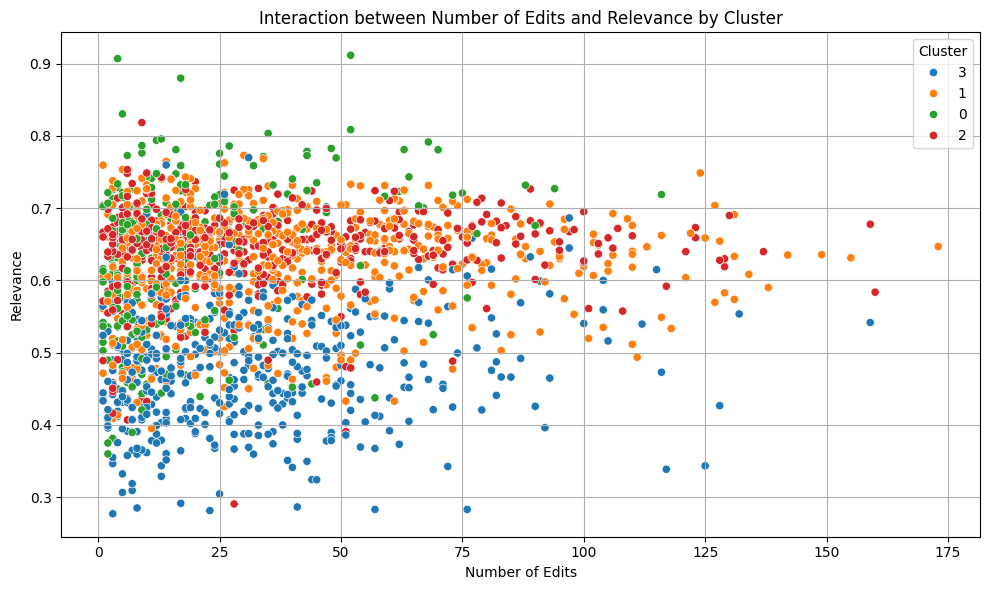

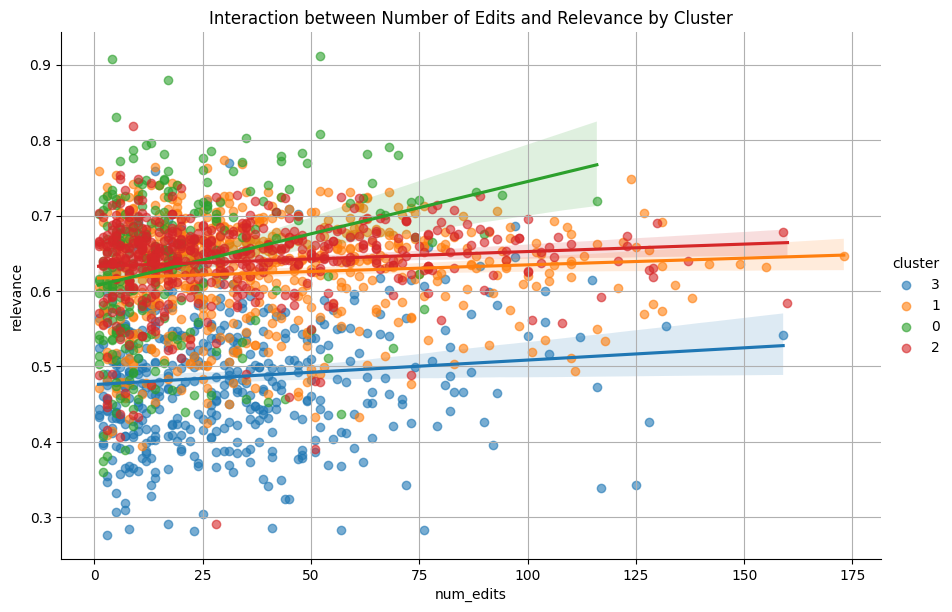

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure cluster column is present (reconstruct if needed)
df_plot = behavioural_scores[['num_edits', 'relevance', 'cluster']].copy()

# Drop missing values
df_plot = df_plot.dropna()

# Convert cluster to string for discrete color mapping
df_plot['cluster'] = df_plot['cluster'].astype(str)

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='num_edits', y='relevance', hue='cluster', palette='tab10')
plt.title('Interaction between Number of Edits and Relevance by Cluster')
plt.xlabel('Number of Edits')
plt.ylabel('Relevance')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

sns.lmplot(
    data=df_plot, 
    x='num_edits', 
    y='relevance', 
    hue='cluster', 
    palette='tab10', 
    height=6, 
    aspect=1.5, 
    scatter_kws={'alpha':0.6}
)
plt.title('Interaction between Number of Edits and Relevance by Cluster')
plt.grid(True)
plt.show()

### Diversity

In [20]:
import pandas as pd
import statsmodels.api as sm

# Copy the relevant columns
# df = behavioural_scores[['num_tracks', 'num_edits', 'cluster', 'diversity']].copy()
df = behavioural_scores[['num_edits', 'cluster', 'diversity']].copy()


# One-hot encode 'cluster' (drop_first=True avoids multicollinearity)
df = pd.get_dummies(df, columns=['cluster'], drop_first=True)

# Ensure boolean columns are converted to integers (0 or 1)
df[['cluster_1', 'cluster_2', 'cluster_3']] = df[['cluster_1', 'cluster_2', 'cluster_3']].astype(int)

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Remove any rows with missing values
df = df.dropna()

# Split into X and y
y = df['diversity']
X = df.drop(columns=['diversity'])

# Add constant for intercept
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Output the model summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              diversity   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     276.2
Date:                Fri, 11 Apr 2025   Prob (F-statistic):          3.26e-186
Time:                        22:27:28   Log-Likelihood:                 2330.3
No. Observations:                1851   AIC:                            -4651.
Df Residuals:                    1846   BIC:                            -4623.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3349      0.004     75.245      0.0

In [21]:
import pandas as pd
import statsmodels.api as sm

# Copy relevant columns
df = behavioural_scores[['num_tracks', 'num_edits', 'cluster', 'diversity']].copy()

# One-hot encode cluster (drop_first=True to avoid dummy variable trap)
df = pd.get_dummies(df, columns=['cluster'], drop_first=True)

# Ensure boolean columns are integers
df[['cluster_1', 'cluster_2', 'cluster_3']] = df[['cluster_1', 'cluster_2', 'cluster_3']].astype(int)

# Create interaction terms
df['edit_x_cluster_1'] = df['num_edits'] * df['cluster_1']
df['edit_x_cluster_2'] = df['num_edits'] * df['cluster_2']
df['edit_x_cluster_3'] = df['num_edits'] * df['cluster_3']

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values
df = df.dropna()

# Define y and X
y = df['diversity']
X = df.drop(columns=['diversity'])

# Add constant
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              diversity   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     143.7
Date:                Fri, 11 Apr 2025   Prob (F-statistic):          7.81e-188
Time:                        22:27:28   Log-Likelihood:                 2345.0
No. Observations:                1851   AIC:                            -4672.
Df Residuals:                    1842   BIC:                            -4622.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3539      0.006  

### Serendipity

In [22]:
import pandas as pd
import statsmodels.api as sm

# Copy the relevant columns
# df = behavioural_scores[['num_tracks', 'num_edits', 'cluster', 'serendipity']].copy()
df = behavioural_scores[['num_edits', 'cluster', 'serendipity']].copy()

# One-hot encode 'cluster' (drop_first=True avoids multicollinearity)
df = pd.get_dummies(df, columns=['cluster'], drop_first=True)

# Ensure boolean columns are converted to integers (0 or 1)
df[['cluster_1', 'cluster_2', 'cluster_3']] = df[['cluster_1', 'cluster_2', 'cluster_3']].astype(int)

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Remove any rows with missing values
df = df.dropna()

# Split into X and y
y = df['serendipity']
X = df.drop(columns=['serendipity'])

# Add constant for intercept
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Output the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            serendipity   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     15.44
Date:                Fri, 11 Apr 2025   Prob (F-statistic):           1.97e-12
Time:                        22:27:28   Log-Likelihood:                 2422.0
No. Observations:                1851   AIC:                            -4834.
Df Residuals:                    1846   BIC:                            -4806.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1900      0.004     44.862      0.0

In [23]:
import pandas as pd
import statsmodels.api as sm

# Copy relevant columns
df = behavioural_scores[['num_tracks', 'num_edits', 'cluster', 'serendipity']].copy()

# One-hot encode cluster (drop_first=True to avoid dummy variable trap)
df = pd.get_dummies(df, columns=['cluster'], drop_first=True)

# Ensure boolean columns are integers
df[['cluster_1', 'cluster_2', 'cluster_3']] = df[['cluster_1', 'cluster_2', 'cluster_3']].astype(int)

# Create interaction terms
df['edit_x_cluster_1'] = df['num_edits'] * df['cluster_1']
df['edit_x_cluster_2'] = df['num_edits'] * df['cluster_2']
df['edit_x_cluster_3'] = df['num_edits'] * df['cluster_3']

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values
df = df.dropna()

# Define y and X
y = df['serendipity']
X = df.drop(columns=['serendipity'])

# Add constant
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            serendipity   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     8.802
Date:                Fri, 11 Apr 2025   Prob (F-statistic):           7.05e-12
Time:                        22:27:28   Log-Likelihood:                 2426.2
No. Observations:                1851   AIC:                            -4834.
Df Residuals:                    1842   BIC:                            -4785.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1802      0.006  

### Regression Analysis Conclusion

At 5% level of significance, we observe that for all 3 behavioural metrics:
- p-value of num_tracks is always > 0.05 
- p-value of num_edits is always < 0.05
- p-value of cluster (at least one cluster) is always < 0.05

We can conclude that num_edits and cluster significantly impacts the outcome of the behavioural metrics.
<br> <br>
This suggests that it is indeed the number of edits a user makes and the nature of the playlist (represented by the cluster) that have a meaningful influence on the outcome, while the number of tracks in the playlist does not appear to have a significant effect.
<br> <br>
This finding highlights that our hybrid model does not require a larger number of tracks in the playlist to generate better recommendations.
<br> <br>
As a result, it can offer high-quality suggestions for users with smaller playlists, reducing the need for large amounts of data. This makes the system more scalable and efficient, providing personalized recommendations even when user input is limited.

# Level 6: Comparing Hybrid Model for Different Clusters

We have shown in Level 3 that our segmentation is effective. 

We will continue to explore if there are any significant differences using the behavioural metrics too, and the systematic reasons behind it.

In [24]:
metrics_df = pd.DataFrame({
    'Avg Relevance': behavioural_scores.groupby('cluster')['relevance'].mean(),
    'Avg Diversity': behavioural_scores.groupby('cluster')['diversity'].mean(),
    'Avg Serendipity': behavioural_scores.groupby('cluster')['serendipity'].mean()
})

print("Evaluation Metrics for Hybrid Model\n")

# Assuming metrics_df is already defined as before
for cluster in metrics_df.index:
    rel = metrics_df.loc[cluster, "Avg Relevance"]
    div = metrics_df.loc[cluster, "Avg Diversity"]
    ser = metrics_df.loc[cluster, "Avg Serendipity"]

    print(f"Metrics for Cluster {cluster}:")
    print(f"Avg Relevance: {rel:.4f}")
    print(f"Avg Diversity: {div:.4f}")
    print(f"Avg Serendipity: {ser:.4f}\n")

Evaluation Metrics for Hybrid Model

Metrics for Cluster 0:
Avg Relevance: 0.6337
Avg Diversity: 0.3298
Avg Serendipity: 0.1862

Metrics for Cluster 1:
Avg Relevance: 0.6241
Avg Diversity: 0.3432
Avg Serendipity: 0.1701

Metrics for Cluster 2:
Avg Relevance: 0.6392
Avg Diversity: 0.3347
Avg Serendipity: 0.1692

Metrics for Cluster 3:
Avg Relevance: 0.4863
Avg Diversity: 0.4586
Avg Serendipity: 0.1938



## F-Test

\begin{aligned}
H_0 &: \mu_{\text{cluster 0}} = \mu_{\text{cluster 1}} = \mu_{\text{cluster 2}} = \mu_{\text{cluster 3}} \quad \text{(No significant difference in the means of the metric across clusters)} \\
H_1 &: \text{At least one } \mu_i \neq \mu_j \quad \text{for some } i \neq j \quad \text{(There is a significant difference in the means of the metric across clusters)}
\end{aligned}

In [25]:
from scipy.stats import f_oneway

# Group the data by the cluster column
grouped = behavioural_scores.groupby('cluster')

# Prepare lists to store values for each behavioral metric
relevance_values = []
diversity_values = []
serendipity_values = []

for cluster, group in grouped:
    relevance_values.append(group["relevance"].values)
    diversity_values.append(group["diversity"].values)
    serendipity_values.append(group["serendipity"].values)

print("F Test between clusters in Behavioral Scores")

# Perform F-tests (ANOVA) for each metric
try:
    f_relevance, p_relevance = f_oneway(*relevance_values)
    f_diversity, p_diversity = f_oneway(*diversity_values)
    f_serendipity, p_serendipity = f_oneway(*serendipity_values)

    # Print the results of the F-tests
    results = {
        "Relevance": {"F-stat": f_relevance, "p-value": p_relevance},
        "Diversity": {"F-stat": f_diversity, "p-value": p_diversity},
        "Serendipity": {"F-stat": f_serendipity, "p-value": p_serendipity}
    }

    for metric, res in results.items():
        f_stat = res['F-stat']
        p_val = res['p-value']

        print(f"\n=== {metric} F-test ===")
        print(f"F-statistic: {f_stat:.3f}")
        print(f"p-value: {p_val:.4f}")
except ValueError as e:
    print(f"Error performing F-test: {e}. Possibly due to insufficient data in one or more clusters.")


F Test between clusters in Behavioral Scores

=== Relevance F-test ===
F-statistic: 415.906
p-value: 0.0000

=== Diversity F-test ===
F-statistic: 357.533
p-value: 0.0000

=== Serendipity F-test ===
F-statistic: 16.286
p-value: 0.0000


Since the p-value for all 3 metrics are close to 0, we reject the null hypothesis, and conclude that there is a significant difference in the metrics for each cluster.

## Clustered Barplot

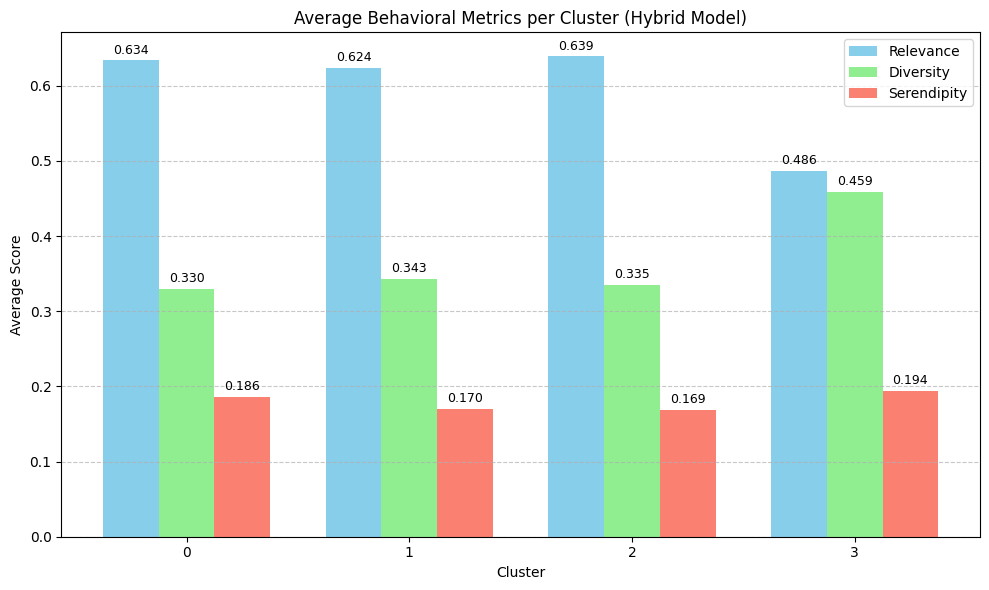

In [26]:
import matplotlib.pyplot as plt

# Reset index to bring cluster as a column for plotting
plot_df = metrics_df.reset_index()

# Set plot size and figure
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.25
clusters = plot_df['cluster']
x = range(len(clusters))

# Positions for each metric
x_relevance = [i - bar_width for i in x]
x_diversity = x
x_serendipity = [i + bar_width for i in x]

# Plot bars
bars_relevance = plt.bar(x_relevance, plot_df['Avg Relevance'], width=bar_width, label='Relevance', color='skyblue')
bars_diversity = plt.bar(x_diversity, plot_df['Avg Diversity'], width=bar_width, label='Diversity', color='lightgreen')
bars_serendipity = plt.bar(x_serendipity, plot_df['Avg Serendipity'], width=bar_width, label='Serendipity', color='salmon')

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height:.3f}', 
                 ha='center', va='bottom', fontsize=9)

add_labels(bars_relevance)
add_labels(bars_diversity)
add_labels(bars_serendipity)

# Labeling
plt.xlabel('Cluster')
plt.ylabel('Average Score')
plt.title('Average Behavioral Metrics per Cluster (Hybrid Model)')
plt.xticks(ticks=x, labels=clusters)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

## Observations & Reason for difference

### **Cluster 0: Consistent Loyalist**
- **High Avg Relevance (0.634)**: Excellent performance; hybrid model accurately captures their strong preferences.
- **Low Diversity & Serendipity** (by design): This aligns with the user profile: they prefer familiar, predictable recommendations.
- **Business Insight**:
  - These users drive **repeat listening** and long-term engagement.
  - Hybrid model keeps them satisfied by reinforcing comfort zones.
  - In our feature fine-tuning in Level 6, from a user perspective, it will be important to **avoid over-recommending** the same tracks to prevent churn from repetition fatigue.

---

### **Cluster 1: Trend-Savvy Seekers**
- **High Relevance (0.624)**: Our hybrid model balances exploration and accuracy for song recommendation.
- **Moderate Diversity & Serendipity**: Lower than expected based on user profile.
  - This could be due to **hybrid weighting favoring collaborative signals**, which tend to recommend popular and less diverse items. As a result, the model **under-explores** for this group.
  - We can consider **weighing content-based filtering more heavily** or using **session-based context** to capture their dynamic interests.
- **Business Insight**:
  - These users are valuable for **catalog exploration** and discovery.
  - Great group for pushing new music, boosting **track exposure** and **launch strategies**.

---

### **Cluster 2: Focused Mood Crafters**
- **Highest Relevance (0.639)**: The model captures their consistent genre/mood focus best.
- **Moderate Diversity (0.335)**: Enough to avoid boredom but not too far from their preferences.
- **Low Serendipity (0.169)**: Acceptable given they do not like surprises. This is expected since **serendipity is calculated as relevance × unexpectedness**, and unexpectedness is low for these users.
- **Business Insight**:
  - Highly predictable users = **easy to personalise**.
  - Our model should emphasize **mood consistency** and **thematic cohesion**.

---

### **Cluster 3: Universal Explorer**
- **Lowest Relevance (0.486)**: The hybrid model **struggles to rank correctly** for such unpredictable users.
- **Highest Diversity (0.459)** and **highest Serendipity (0.194)**: The model captures novelty well but **sacrifices accuracy** in doing so.
- **Business Insight**:
  - This group is slightly more difficult to model due to **sparse and irregular behavior**.
  - Value comes from **playlist generation, social features, and content discovery**.
  - In our feature fine-tuning in Level 6, from a user perspective, we can focus on **exploration-heavy hybrid** (e.g weigh heavier on collaborative filtering) to retain Cluster 3's interest.

---

### **Summary**

| Cluster | Listener Type              | Avg Relevance  | Avg Diversity  | Avg Serendipity  | Hybrid Strength             | Key Limitation                      |
|---------|----------------------------|----------------|----------------|------------------|-----------------------------|-------------------------------------|
| 0       | Consistent Loyalist        | 0.6337         | 0.3298         | 0.1862           | High accuracy               | Low novelty                         |
| 1       | Trend-Savvy Seekers        | 0.6241         | 0.3432         | 0.1701           | Balanced personalization    | Slightly under-serendipitous        |
| 2       | Focused Mood Crafters      | 0.6392         | 0.3347         | 0.1692           | Very high relevance         | Predictable                         |
| 3       | Universal Explorer         | 0.4863         | 0.4586         | 0.1938           | High novelty & diversity    | Lower accuracy                      |

---

### **Business Takeaway**

> By aligning hybrid model performance with **behavioral segments**, we can optimise the recommendation strategy per playlist type. This ensures that:
- Loyalists get **reliable favorites**,
- Trend seekers find **new music**,
- Mood crafters stay in their **emotional lane**,
- And universal explorers are given **room to discover**.

In doing so, our recommendation system (Spotifind) can **maximise engagement, discovery, and user satisfaction**, directly contributing to **longer session times**, **reduced churn**, and **greater catalog exposure** for Spotify.

# Conclusion

**For our the final model, we will adjust the weights for the hybrid model (Content-Based & Collaborative Filtering), and the feature weights to achieve desired scores for each cluster based on the business strategy and nature of each playlist.**